<a href="https://colab.research.google.com/github/Arisudan/Projects/blob/main/AI_Driver_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Driver Risk Prediction System (Tesla-Style Dashboard)

This notebook implements a real-time AI Driver Risk Prediction System with a unified Tesla-style dashboard UI, integrating video processing, object detection, lane detection, risk assessment, and live analytics into a single, continuously updating display.

In [115]:
# 1. ENVIRONMENT SETUP

!pip install ultralytics opencv-python numpy matplotlib scikit-learn ipywidgets --quiet

In [116]:
# Essential Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from ultralytics import YOLO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import random
import math

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [117]:
# 2. VIDEO DATASET
import utils
# Re-download with the updated specific driving videos
utils.download_videos()

videos/video1.mp4 already exists.
videos/video2.avi already exists.
videos/video3.mov already exists.
videos/video4.mp4 already exists.
Video download complete.


In [118]:
# 3. VIDEO SELECTION UI & 4. CONTROL PANEL

video_files = [f for f in os.listdir('videos/') if f.endswith(('.mp4', '.avi', '.mov'))]
video_dropdown = widgets.Dropdown(
    options={f"Video {i+1}: {f}": os.path.join('videos/', f) for i, f in enumerate(video_files)},
    description='Select Video:',
    disabled=False,
)

play_button = widgets.Button(description="Play", button_style='success')
pause_button = widgets.Button(description="Pause", button_style='warning')
status_label = widgets.Label(value="Status: READY")

control_panel = widgets.HBox([
    video_dropdown,
    play_button,
    pause_button,
    status_label
])

# Global control variables
is_playing = False
current_frame_idx = 0
cap = None

# New UI elements for display
image_widget = widgets.Image(format='jpeg', width=1280, height=720 + 200) # Assuming dashboard + graph height
output_area = widgets.Output() # Dedicated output area for displaying the image and debug prints

# Combine control panel and output area into a single VBox
main_ui_display = widgets.VBox([
    control_panel,
    output_area
])

# Display the image widget once within the output_area so it's always there
with output_area:
    display(image_widget)

In [119]:
# 5. YOLO OBJECT DETECTION

yolo_model = YOLO('yolov8n.pt') # Load YOLOv8n model

# Classes for vehicles and persons in COCO dataset
# COCO dataset classes: 0: person, 1: bicycle, 2: car, 3: motorcycle, 5: bus, 7: truck
VEHICLE_CLASSES = [2, 3, 5, 7] # car, motorcycle, bus, truck
PERSON_CLASS = 0

In [120]:
# 6. LANE DETECTION

def detect_lanes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150) # Canny edge detector

    height, width = frame.shape[:2]
    # Define a region of interest (ROI) for lane detection
    # This simple ROI assumes the camera is mounted looking forward
    roi_vertices = [
        (0, height),
        (width / 2 - 50, height / 2 + 50),
        (width / 2 + 50, height / 2 + 50),
        (width, height)
    ]
    mask = np.zeros_like(canny)
    cv2.fillPoly(mask, [np.array(roi_vertices, dtype=np.int32)], 255)
    masked_canny = cv2.bitwise_and(canny, mask)

    lines = cv2.HoughLinesP(masked_canny, 1, np.pi/180, 50, minLineLength=50, maxLineGap=5)
    lane_lines_image = np.zeros_like(frame)

    if lines is not None:
        # Process lines to get two dominant lane lines (left and right)
        left_lines = []
        right_lines = []

        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2: # Avoid division by zero
                continue
            slope = (y2 - y1) / (x2 - x1)
            if abs(slope) < 0.2: # Filter out horizontal lines
                continue
            if slope < 0: # Negative slope -> left lane
                left_lines.append(line[0])
            else: # Positive slope -> right lane
                right_lines.append(line[0])

        def average_slope_intercept(lines):
            if not lines: return None
            slopes = []
            intercepts = []
            for x1, y1, x2, y2 in lines:
                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1
                slopes.append(slope)
                intercepts.append(intercept)
            avg_slope = np.mean(slopes)
            avg_intercept = np.mean(intercepts)
            return avg_slope, avg_intercept

        def make_coordinates(frame, line_params):
            if line_params is None: return None
            slope, intercept = line_params
            y1 = int(height) # bottom of the image
            y2 = int(height * 0.6) # slightly above the middle
            x1 = int((y1 - intercept) / slope)
            x2 = int((y2 - intercept) / slope)
            return np.array([x1, y1, x2, y2])

        left_line_params = average_slope_intercept(left_lines)
        right_line_params = average_slope_intercept(right_lines)

        left_fit_line = make_coordinates(frame, left_line_params)
        right_fit_line = make_coordinates(frame, right_line_params)

        if left_fit_line is not None:
            x1, y1, x2, y2 = left_fit_line
            cv2.line(lane_lines_image, (x1, y1), (x2, y2), (0, 255, 0), 10)
        if right_fit_line is not None:
            x1, y1, x2, y2 = right_fit_line
            cv2.line(lane_lines_image, (x1, y1), (x2, y2), (0, 255, 0), 10)

    return cv2.addWeighted(frame, 0.8, lane_lines_image, 1, 1)

In [121]:
# 7. FEATURE EXTRACTION

def extract_features(detections):
    vehicle_boxes = []
    person_boxes = []

    for *xyxy, conf, cls in detections.xyxy[0]:
        if int(cls) in VEHICLE_CLASSES:
            vehicle_boxes.append(np.array(xyxy).astype(int))
        elif int(cls) == PERSON_CLASS:
            person_boxes.append(np.array(xyxy).astype(int))

    vehicle_count = len(vehicle_boxes)
    person_count = len(person_boxes)

    min_distance = float('inf')
    if vehicle_count > 1:
        for i in range(vehicle_count):
            for j in range(i + 1, vehicle_count):
                box1 = vehicle_boxes[i]
                box2 = vehicle_boxes[j]
                center1 = ((box1[0] + box1[2]) // 2, (box1[1] + box1[3]) // 2)
                center2 = ((box2[0] + box2[2]) // 2, (box2[1] + box2[3]) // 2)
                dist = np.sqrt((center1[0] - center2[0])**2 + (center1[1] - center2[1])**2)
                min_distance = min(min_distance, dist)

    # Simple object density: sum of areas of bounding boxes / total frame area
    frame_area = 1280 * 720 # Assuming a common frame size, adjust if dynamic
    object_area_sum = 0
    for box in vehicle_boxes + person_boxes:
        object_area_sum += (box[2] - box[0]) * (box[3] - box[1])
    object_density = object_area_sum / frame_area if frame_area > 0 else 0

    # Centers of all detected objects for motion tracking
    object_centers = []
    for box in vehicle_boxes + person_boxes:
        object_centers.append(((box[0] + box[2]) // 2, (box[1] + box[3]) // 2))

    return vehicle_count, min_distance, object_density, object_centers, vehicle_boxes, person_boxes

In [122]:
# 8. SPEED ESTIMATION

# Simple object tracking using centroids. This is a basic approach and can be improved.
previous_object_centers = {}
object_speed = {}
object_id_counter = 0

def estimate_speed(current_object_centers, frame_time_diff):
    global previous_object_centers, object_speed, object_id_counter

    new_object_speed = {}
    matched_current_centers = []
    matched_prev_centers = []

    # Simple matching based on minimum distance to previous frame's objects
    for curr_center in current_object_centers:
        min_dist = float('inf')
        best_match_id = None
        for obj_id, prev_center in previous_object_centers.items():
            dist = np.sqrt((curr_center[0] - prev_center[0])**2 + (curr_center[1] - prev_center[1])**2)
            if dist < min_dist and dist < 100: # Threshold for matching
                min_dist = dist
                best_match_id = obj_id

        if best_match_id is not None:
            if frame_time_diff > 0:
                speed_px_s = min_dist / frame_time_diff
            else:
                speed_px_s = 0
            new_object_speed[best_match_id] = speed_px_s
            matched_current_centers.append(curr_center)
            matched_prev_centers.append(previous_object_centers[best_match_id])
        else:
            # New object detected
            object_id_counter += 1
            new_object_speed[object_id_counter] = 0 # Initialize speed for new objects

    previous_object_centers = {}
    for i, center in enumerate(matched_current_centers):
        # Reassign previous centers based on current matches to track for next frame
        # This simplified logic might lose track of objects that momentarily disappear or don't match
        previous_object_centers[list(new_object_speed.keys())[i]] = center

    # Update global object_speed, potentially add new objects and remove lost ones
    object_speed = new_object_speed

    # Calculate average speed if multiple objects are tracked
    avg_speed = np.mean(list(object_speed.values())) if object_speed else 0
    return avg_speed

In [123]:
# 9. MACHINE LEARNING RISK MODEL

risk_model = None

def train_model():
    global risk_model
    print("Training risk prediction model...")

    # Generate synthetic data for training
    data = []
    for _ in range(1000):
        vehicle_count = random.randint(0, 20)
        min_distance = random.uniform(50, 500) if vehicle_count > 1 else 1000 # Larger distance if few vehicles
        object_density = random.uniform(0.01, 0.5)

        # Define risk based on features
        risk = 0 # LOW
        if vehicle_count > 8 and min_distance < 150:
            risk = 2 # HIGH
        elif (vehicle_count > 5 and min_distance < 250) or object_density > 0.3:
            risk = 1 # MEDIUM

        data.append([vehicle_count, min_distance, object_density, risk])

    df_synthetic = pd.DataFrame(data, columns=['vehicle_count', 'min_distance', 'object_density', 'risk'])

    X = df_synthetic[['vehicle_count', 'min_distance', 'object_density']]
    y = df_synthetic['risk']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    risk_model = RandomForestClassifier(n_estimators=100, random_state=42)
    risk_model.fit(X_train, y_train)

    y_pred = risk_model.predict(X_test)
    print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Risk prediction model trained.")

train_model()

Training risk prediction model...
Model Accuracy: 1.00
Risk prediction model trained.


In [124]:
# 10. TESLA-STYLE UI OVERLAY & 11. COLLISION WARNING SYSTEM

RISK_COLORS = [(0, 255, 0), (0, 255, 255), (0, 0, 255)] # BGR: GREEN, YELLOW, RED
RISK_LABELS = ["LOW", "MEDIUM", "HIGH"]

risk_history = []
MAX_RISK_HISTORY = 100 # For the live graph

def create_dashboard_frame(frame, risk_score, current_speed, status):
    h, w, _ = frame.shape
    overlay = frame.copy()
    output = frame.copy()

    # Top semi-transparent dark bar
    cv2.rectangle(overlay, (0, 0), (w, 60), (0, 0, 0), -1) # Black bar
    alpha = 0.6 # Transparency factor.
    frame = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)

    # Title: AI DRIVER ASSIST SYSTEM
    cv2.putText(frame, "AI DRIVER ASSIST SYSTEM", (w // 2 - 150, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # Risk label (large, colored)
    risk_color = RISK_COLORS[risk_score]
    risk_text = RISK_LABELS[risk_score]
    cv2.putText(frame, f"RISK: {risk_text}", (30, h - 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, risk_color, 3, cv2.LINE_AA)

    # Speed display
    cv2.putText(frame, f"Speed: {current_speed:.0f} px/s", (30, h - 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # Status display
    cv2.putText(frame, f"Status: {status}", (w - 250, h - 100), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

    # Add border around frame
    cv2.rectangle(frame, (0, 0), (w - 1, h - 1), (255, 255, 255), 5)

    # Radar circle at bottom center
    radar_center = (w // 2, h - 80) # Position radar above risk label
    radar_radius = 60
    cv2.circle(frame, radar_center, radar_radius, (255, 255, 255), 2) # Circle outline
    cv2.circle(frame, radar_center, 8, risk_color, -1) # Center dot color based on risk

    # Collision Warning System
    if risk_score == 2: # HIGH risk
        # Red arrows
        arrow_size = 50
        arrow_thickness = 5
        # Left arrow
        cv2.arrowedLine(frame, (w // 4, h // 2), (w // 4 - arrow_size, h // 2), (0, 0, 255), arrow_thickness, tipLength=0.5)
        # Right arrow
        cv2.arrowedLine(frame, (3 * w // 4, h // 2), (3 * w // 4 + arrow_size, h // 2), (0, 0, 255), arrow_thickness, tipLength=0.5)

        # "COLLISION WARNING" text
        text_warning = "COLLISION WARNING"
        text_size = cv2.getTextSize(text_warning, cv2.FONT_HERSHEY_SIMPLEX, 2, 5)[0]
        text_x = (w - text_size[0]) // 2
        text_y = h // 2 + text_size[1] // 2
        cv2.putText(frame, text_warning, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5, cv2.LINE_AA)

    return frame

In [125]:
def plot_risk_graph(risk_history):
    fig, ax = plt.subplots(figsize=(10, 2), dpi=100)
    ax.plot(risk_history, color='orange', linewidth=2)
    ax.set_ylim(-0.5, 2.5) # Risk scores are 0, 1, 2
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(RISK_LABELS)
    ax.set_xlabel("Time (frames)")
    ax.set_ylabel("Risk Level")
    ax.set_title("Live Risk Trend")
    ax.grid(True)
    plt.tight_layout()

    # Convert matplotlib graph to image
    fig.canvas.draw()
    img_np = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img_np = img_np.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig) # Close the plot to free memory
    return img_np

def process_video(video_path):
    global is_playing, current_frame_idx, cap, risk_history, previous_object_centers, object_id_counter, image_widget, output_area

    with output_area: # Route all prints to this specific output area
        print(f"[DEBUG] Starting process_video for: {video_path}")
    if not os.path.exists(video_path):
        status_label.value = f"Status: Error - Video not found: {video_path}"
        with output_area: print(f"[DEBUG] Error: Video not found at {video_path}")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        status_label.value = f"Status: Error - Could not open video: {video_path}"
        with output_area: print(f"[DEBUG] Error: Could not open video capture for {video_path}")
        return

    current_frame_idx = 0
    risk_history = []
    previous_object_centers = {}
    object_id_counter = 0

    prev_frame_time = time.time()

    with output_area: # Clear the output area for new video stream and ensure image widget is displayed
        clear_output(wait=True)
        display(image_widget) # Ensure the image widget is always at the top of the output_area

    while True:
        if is_playing:
            with output_area: print(f"[DEBUG] Processing frame {current_frame_idx}")
            cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame_idx)
            ret, frame = cap.read()

            if not ret:
                status_label.value = "Status: END OF VIDEO"
                is_playing = False
                cap.release()
                with output_area: print("[DEBUG] End of video or failed to read frame. Exiting loop.")
                break

            current_frame_time = time.time()
            frame_time_diff = current_frame_time - prev_frame_time
            prev_frame_time = current_frame_time

            frame = cv2.resize(frame, (1280, 720))

            frame_with_lanes = detect_lanes(frame.copy())
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Lane detection complete.")

            results = yolo_model(frame_with_lanes, verbose=False)
            detections = results[0]
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: YOLO object detection complete. Detections: {len(detections.boxes)} objects.")

            vehicle_count, min_distance, object_density, object_centers, vehicle_boxes, person_boxes = extract_features(detections)
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Feature extraction complete. Vehicles: {vehicle_count}, Min Distance: {min_distance:.2f}.")

            avg_speed = estimate_speed(object_centers, frame_time_diff)
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Speed estimation complete. Avg Speed: {avg_speed:.2f}.")

            for box in vehicle_boxes:
                cv2.rectangle(frame_with_lanes, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
            for box in person_boxes:
                cv2.rectangle(frame_with_lanes, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)

            features = np.array([[vehicle_count, min_distance, object_density]])
            features[features == float('inf')] = 1000
            if risk_model:
                risk_prediction = risk_model.predict(features)[0]
            else:
                risk_prediction = 0
            risk_history.append(risk_prediction)
            if len(risk_history) > MAX_RISK_HISTORY:
                risk_history.pop(0)
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Risk prediction complete. Risk: {RISK_LABELS[risk_prediction]}.")

            dashboard_frame = create_dashboard_frame(frame_with_lanes, risk_prediction, avg_speed, "RUNNING")
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Dashboard frame created.")

            risk_graph_img = plot_risk_graph(risk_history)
            with output_area: print(f"[DEBUG] Frame {current_frame_idx}: Risk graph image created.")

            combined_dashboard = np.vstack((dashboard_frame, risk_graph_img))
            combined_dashboard = cv2.cvtColor(combined_dashboard, cv2.COLOR_BGR2RGB)

            # Convert numpy array to JPEG bytes for ipywidgets.Image
            _, encoded_image = cv2.imencode('.jpeg', combined_dashboard)
            image_widget.value = encoded_image.tobytes()

            current_frame_idx += 1
            time.sleep(0.01)

        else:
            time.sleep(0.1)

    cap.release()
    with output_area:
        clear_output(wait=True)
        print("[DEBUG] Video processing finished.")


def on_play_clicked(b):
    global is_playing, cap
    if not is_playing:
        is_playing = True
        status_label.value = "Status: RUNNING"
        selected_video_path = video_dropdown.value
        # If a video is already playing and paused, resume it.
        # If a new video is selected or no video is playing, start a new one.
        if cap is None or not cap.isOpened() or cap.get(cv2.CAP_PROP_POS_FRAMES) >= cap.get(cv2.CAP_PROP_FRAME_COUNT) or cap.get(cv2.CAP_PROP_POS_FRAMES) == 0:
             # Start a new thread for video processing to avoid blocking the UI
            import threading
            with output_area: print(f"[DEBUG] Starting new thread for video processing: {selected_video_path}")
            threading.Thread(target=process_video, args=(selected_video_path,)).start()
        else:
            with output_area: print(f"[DEBUG] Resuming video processing for: {selected_video_path}")

def on_pause_clicked(b):
    global is_playing
    is_playing = False
    status_label.value = "Status: PAUSED"
    with output_area: print("[DEBUG] Video paused.")

def on_video_selected(change):
    global is_playing, cap, current_frame_idx, risk_history, previous_object_centers, object_id_counter
    if is_playing: # If a video is playing, stop it and reset
        is_playing = False
        if cap and cap.isOpened():
            cap.release()
        cap = None
    with output_area: print(f"[DEBUG] Video selected: {change.new}")
    current_frame_idx = 0
    risk_history = []
    previous_object_centers = {}
    object_id_counter = 0
    status_label.value = f"Status: READY - {os.path.basename(change.new)}"


play_button.on_click(on_play_clicked)
pause_button.on_click(on_pause_clicked)
video_dropdown.observe(on_video_selected, names='value')

In [126]:
# Display the main UI container, which includes the control panel and the video output area.
display(main_ui_display)

## Refactoring Core Logic into Modular Scripts for Deployment

To prepare the core logic for deployment and make it more modular, we will create several `.py` files, each handling a specific part of the system. This separation of concerns improves maintainability, reusability, and makes it easier to integrate into a standalone application or a web service.

### 1. `config.py`
This file will store all the constant values and configurations used across the system.

In [127]:
%%writefile config.py

# Configuration Constants for AI Driver Risk Prediction System

# YOLO Object Detection
VEHICLE_CLASSES = [2, 3, 5, 7]  # COCO classes: car, motorcycle, bus, truck
PERSON_CLASS = 0                # COCO class: person

# Risk Assessment
RISK_COLORS = [(0, 255, 0), (0, 255, 255), (0, 0, 255)] # BGR: GREEN, YELLOW, RED
RISK_LABELS = ["LOW", "MEDIUM", "HIGH"]
MAX_RISK_HISTORY = 100          # Number of frames to keep for risk trend graph

# Display/UI
FRAME_WIDTH = 1280
FRAME_HEIGHT = 720
GRAPH_HEIGHT = 200 # Height for the risk graph when combined with dashboard


Overwriting config.py


### 2. `utils.py`
This file will contain general utility functions, such as video downloading and the risk graph plotting function (modified to return an image array).

In [128]:
%%writefile utils.py

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from config import RISK_LABELS

def download_videos():
    # Using higher-quality driving samples suitable for ADAS testing
    video_data = [
        {"name": "Highway.mp4", "url": "https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection-adtl-2021.mp4"},
        {"name": "Traffic.mp4", "url": "https://github.com/intel-iot-devkit/sample-videos/raw/master/driver-action-recognition-0001.mp4"},
        {"name": "City.mp4", "url": "https://github.com/intel-iot-devkit/sample-videos/raw/master/passenger-detection-0001.mp4"}
    ]

    video_folder = "videos/"
    os.makedirs(video_folder, exist_ok=True)

    print("Downloading driving-specific sample videos...")
    for item in video_data:
        local_filename = os.path.join(video_folder, item["name"])
        if not os.path.exists(local_filename):
            try:
                response = requests.get(item["url"], stream=True)
                response.raise_for_status()
                with open(local_filename, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"Downloaded {local_filename}")
            except Exception as e:
                print(f"Could not download {item['name']}: {e}")
        else:
            print(f"{local_filename} already exists.")

def plot_risk_graph(risk_history, max_risk_history, risk_labels):
    fig, ax = plt.subplots(figsize=(10, 2), dpi=100)
    ax.plot(risk_history, color='orange', linewidth=2)
    ax.set_ylim(-0.5, len(risk_labels) - 0.5)
    ax.set_yticks(range(len(risk_labels)))
    ax.set_yticklabels(risk_labels)
    ax.set_xlabel("Time (frames)")
    ax.set_ylabel("Risk Level")
    ax.set_title("Live Risk Trend")
    ax.grid(True)
    plt.tight_layout()

    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    img_np = np.asarray(buf)
    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGBA2RGB)
    plt.close(fig)
    return img_np

Overwriting utils.py


### 3. `vision.py`
This module will encapsulate the computer vision-related tasks: lane detection, object feature extraction, and speed estimation.

In [129]:
%%writefile vision.py

import cv2
import numpy as np
from config import VEHICLE_CLASSES, PERSON_CLASS, FRAME_WIDTH, FRAME_HEIGHT

class ObjectTracker:
    def __init__(self):
        self.previous_object_centers = {}
        self.object_speed = {}
        self.object_id_counter = 0

    def estimate_speed(self, current_object_centers, frame_time_diff):
        new_object_speed = {}
        matched_current_centers = []
        matched_prev_centers = []

        # Simple matching based on minimum distance to previous frame's objects
        for curr_center in current_object_centers:
            min_dist = float('inf')
            best_match_id = None
            for obj_id, prev_center in self.previous_object_centers.items():
                dist = np.sqrt((curr_center[0] - prev_center[0])**2 + (curr_center[1] - prev_center[1])**2)
                if dist < min_dist and dist < 100: # Threshold for matching
                    min_dist = dist
                    best_match_id = obj_id

            if best_match_id is not None:
                if frame_time_diff > 0:
                    speed_px_s = min_dist / frame_time_diff
                else:
                    speed_px_s = 0
                new_object_speed[best_match_id] = speed_px_s
                matched_current_centers.append(curr_center)
                matched_prev_centers.append(self.previous_object_centers[best_match_id])
            else:
                # New object detected
                self.object_id_counter += 1
                new_object_speed[self.object_id_counter] = 0 # Initialize speed for new objects

        self.previous_object_centers = {}
        for i, center in enumerate(matched_current_centers):
            # Reassign previous centers based on current matches to track for next frame
            # This simplified logic might lose track of objects that momentarily disappear or don't match
            self.previous_object_centers[list(new_object_speed.keys())[i]] = center

        # Update global object_speed, potentially add new objects and remove lost ones
        self.object_speed = new_object_speed

        # Calculate average speed if multiple objects are tracked
        avg_speed = np.mean(list(self.object_speed.values())) if self.object_speed else 0
        return avg_speed

def detect_lanes(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150) # Canny edge detector

    height, width = frame.shape[:2]
    # Define a region of interest (ROI) for lane detection
    roi_vertices = [
        (0, height),
        (width / 2 - 50, height / 2 + 50),
        (width / 2 + 50, height / 2 + 50),
        (width, height)
    ]
    mask = np.zeros_like(canny)
    cv2.fillPoly(mask, [np.array(roi_vertices, dtype=np.int32)], 255)
    masked_canny = cv2.bitwise_and(canny, mask)

    lines = cv2.HoughLinesP(masked_canny, 1, np.pi/180, 50, minLineLength=50, maxLineGap=5)
    lane_lines_image = np.zeros_like(frame)

    if lines is not None:
        left_lines = []
        right_lines = []

        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2:
                continue
            slope = (y2 - y1) / (x2 - x1)
            if abs(slope) < 0.2:
                continue
            if slope < 0:
                left_lines.append(line[0])
            else:
                right_lines.append(line[0])

        def average_slope_intercept(lines):
            if not lines: return None
            slopes = []
            intercepts = []
            for x1, y1, x2, y2 in lines:
                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1
                slopes.append(slope)
                intercepts.append(intercept)
            avg_slope = np.mean(slopes)
            avg_intercept = np.mean(intercepts)
            return avg_slope, avg_intercept

        def make_coordinates(frame, line_params):
            if line_params is None: return None
            slope, intercept = line_params
            y1 = int(height) # bottom of the image
            y2 = int(height * 0.6) # slightly above the middle
            x1 = int((y1 - intercept) / slope)
            x2 = int((y2 - intercept) / slope)
            return np.array([x1, y1, x2, y2])

        left_line_params = average_slope_intercept(left_lines)
        right_line_params = average_slope_intercept(right_lines)

        left_fit_line = make_coordinates(frame, left_line_params)
        right_fit_line = make_coordinates(frame, right_line_params)

        if left_fit_line is not None:
            x1, y1, x2, y2 = left_fit_line
            cv2.line(lane_lines_image, (x1, y1), (x2, y2), (0, 255, 0), 10)
        if right_fit_line is not None:
            x1, y1, x2, y2 = right_fit_line
            cv2.line(lane_lines_image, (x1, y1), (x2, y2), (0, 255, 0), 10)

    return cv2.addWeighted(frame, 0.8, lane_lines_image, 1, 1)

def extract_features(detections):
    vehicle_boxes = []
    person_boxes = []

    if detections is not None and hasattr(detections, 'boxes') and detections.boxes is not None:
        for *xyxy, conf, cls in detections.boxes.data:
            if int(cls) in VEHICLE_CLASSES:
                vehicle_boxes.append(np.array(xyxy).astype(int))
            elif int(cls) == PERSON_CLASS:
                person_boxes.append(np.array(xyxy).astype(int))

    vehicle_count = len(vehicle_boxes)
    person_count = len(person_boxes)

    min_distance = float('inf')
    if vehicle_count > 1:
        for i in range(vehicle_count):
            for j in range(i + 1, vehicle_count):
                box1 = vehicle_boxes[i]
                box2 = vehicle_boxes[j]
                center1 = ((box1[0] + box1[2]) // 2, (box1[1] + box1[3]) // 2)
                center2 = ((box2[0] + box2[2]) // 2, (box2[1] + box2[3]) // 2)
                dist = np.sqrt((center1[0] - center2[0])**2 + (center1[1] - center2[1])**2)
                min_distance = min(min_distance, dist)

    frame_area = FRAME_WIDTH * FRAME_HEIGHT # Assuming a common frame size, adjust if dynamic
    object_area_sum = 0
    for box in vehicle_boxes + person_boxes:
        object_area_sum += (box[2] - box[0]) * (box[3] - box[1])
    object_density = object_area_sum / frame_area if frame_area > 0 else 0

    object_centers = []
    for box in vehicle_boxes + person_boxes:
        object_centers.append(((box[0] + box[2]) // 2, (box[1] + box[3]) // 2))

    return vehicle_count, min_distance, object_density, object_centers, vehicle_boxes, person_boxes


Overwriting vision.py


### 4. `risk_assessment.py`
This file will handle the machine learning model for risk prediction, including training and making predictions.

In [130]:
%%writefile risk_assessment.py

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random

class RiskPredictor:
    def __init__(self):
        self.model = None

    def train_model(self):
        print("Training risk prediction model...")

        # Generate synthetic data for training
        data = []
        for _ in range(1000):
            vehicle_count = random.randint(0, 20)
            min_distance = random.uniform(50, 500) if vehicle_count > 1 else 1000 # Larger distance if few vehicles
            object_density = random.uniform(0.01, 0.5)

            # Define risk based on features
            risk = 0 # LOW
            if vehicle_count > 8 and min_distance < 150:
                risk = 2 # HIGH
            elif (vehicle_count > 5 and min_distance < 250) or object_density > 0.3:
                risk = 1 # MEDIUM

            data.append([vehicle_count, min_distance, object_density, risk])

        df_synthetic = pd.DataFrame(data, columns=['vehicle_count', 'min_distance', 'object_density', 'risk'])

        X = df_synthetic[['vehicle_count', 'min_distance', 'object_density']]
        y = df_synthetic['risk']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.model.fit(X_train, y_train)

        y_pred = self.model.predict(X_test)
        print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
        print("Risk prediction model trained.")

    def predict_risk(self, vehicle_count, min_distance, object_density):
        if self.model is None:
            print("Risk model not trained. Returning default LOW risk.")
            return 0 # Default to LOW risk if model not trained

        features = np.array([[vehicle_count, min_distance, object_density]])
        # Handle inf values if min_distance was inf due to no other vehicles
        features[features == float('inf')] = 1000
        return self.model.predict(features)[0]


Overwriting risk_assessment.py


### 5. `dashboard_renderer.py`
This module will handle the visual overlay for the Tesla-style dashboard elements onto the video frame.

In [131]:
%%writefile dashboard_renderer.py

import cv2
import numpy as np
from config import RISK_COLORS, RISK_LABELS

def create_dashboard_frame(frame, risk_score, current_speed, status):
    h, w, _ = frame.shape
    overlay = frame.copy()

    # Top semi-transparent dark bar
    cv2.rectangle(overlay, (0, 0), (w, 60), (0, 0, 0), -1) # Black bar
    alpha = 0.6 # Transparency factor.
    frame = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)

    # Title: AI DRIVER ASSIST SYSTEM
    cv2.putText(frame, "AI DRIVER ASSIST SYSTEM", (w // 2 - 150, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # Risk label (large, colored)
    risk_color = RISK_COLORS[risk_score]
    risk_text = RISK_LABELS[risk_score]
    cv2.putText(frame, f"RISK: {risk_text}", (30, h - 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, risk_color, 3, cv2.LINE_AA)

    # Speed display
    cv2.putText(frame, f"Speed: {current_speed:.0f} px/s", (30, h - 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    # Status display
    cv2.putText(frame, f"Status: {status}", (w - 250, h - 100), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

    # Add border around frame
    cv2.rectangle(frame, (0, 0), (w - 1, h - 1), (255, 255, 255), 5)

    # Radar circle at bottom center
    radar_center = (w // 2, h - 80) # Position radar above risk label
    radar_radius = 60
    cv2.circle(frame, radar_center, radar_radius, (255, 255, 255), 2) # Circle outline
    cv2.circle(frame, radar_center, 8, risk_color, -1) # Center dot color based on risk

    # Collision Warning System
    if risk_score == 2: # HIGH risk
        # Red arrows
        arrow_size = 50
        arrow_thickness = 5
        # Left arrow
        cv2.arrowedLine(frame, (w // 4, h // 2), (w // 4 - arrow_size, h // 2), (0, 0, 255), arrow_thickness, tipLength=0.5)
        # Right arrow
        cv2.arrowedLine(frame, (3 * w // 4, h // 2), (3 * w // 4 + arrow_size, h // 2), (0, 0, 255), arrow_thickness, tipLength=0.5)

        # "COLLISION WARNING" text
        text_warning = "COLLISION WARNING"
        text_size = cv2.getTextSize(text_warning, cv2.FONT_HERSHEY_SIMPLEX, 2, 5)[0]
        text_x = (w - text_size[0]) // 2
        text_y = h // 2 + text_size[1] // 2
        cv2.putText(frame, text_warning, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5, cv2.LINE_AA)

    return frame


Overwriting dashboard_renderer.py


### 6. `main.py`
This is the main script that orchestrates all the modules. It will load models, process video frames, apply vision tasks, predict risk, render the dashboard, and display the output using `cv2.imshow` for a standalone application. It will replace the complex `process_video` function in the notebook and rely on the new modular files.

_Note: `cv2.imshow` typically requires a display server and won't work directly in a headless Colab environment without specific setup (e.g., Xvfb). For direct execution in Colab, you would need to convert frames to bytes and display them via `IPython.display.Image` or `ipywidgets.Image` (as originally done). This `main.py` is structured for a local machine with a display._

In [132]:
%%writefile main.py

import cv2
import time
import os
import sys # Import sys module
from ultralytics import YOLO
import warnings
import numpy as np # Import numpy

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add current directory to sys.path to allow importing local modules
sys.path.append(os.path.abspath('.'))

# Import modules
from config import FRAME_WIDTH, FRAME_HEIGHT, MAX_RISK_HISTORY, RISK_LABELS, GRAPH_HEIGHT
from utils import download_videos, plot_risk_graph
from vision import detect_lanes, extract_features, ObjectTracker
from risk_assessment import RiskPredictor
from dashboard_renderer import create_dashboard_frame

class DriverAssistSystem:
    def __init__(self, yolo_model_path='yolov8n.pt'):
        print("Initializing Driver Assist System...")
        self.yolo_model = YOLO(yolo_model_path)
        print("YOLO model loaded.")

        self.risk_predictor = RiskPredictor()
        self.risk_predictor.train_model()

        self.object_tracker = ObjectTracker()

        self.risk_history = []
        self.prev_frame_time = 0

    def process_frame(self, frame, frame_idx):
        current_frame_time = time.time()
        frame_time_diff = current_frame_time - self.prev_frame_time
        if self.prev_frame_time == 0: # First frame
            frame_time_diff = 0.01 # Prevent division by zero, arbitrary small value
        self.prev_frame_time = current_frame_time

        frame = cv2.resize(frame, (FRAME_WIDTH, FRAME_HEIGHT))

        # 1. Lane Detection
        frame_with_lanes = detect_lanes(frame.copy())

        # 2. Object Detection
        results = self.yolo_model(frame_with_lanes, verbose=False)
        detections = results[0]

        # 3. Feature Extraction
        vehicle_count, min_distance, object_density, object_centers, vehicle_boxes, person_boxes = extract_features(detections)

        # Draw bounding boxes (optional, for visualization)
        for box in vehicle_boxes:
            cv2.rectangle(frame_with_lanes, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        for box in person_boxes:
            cv2.rectangle(frame_with_lanes, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)

        # 4. Speed Estimation
        avg_speed = self.object_tracker.estimate_speed(object_centers, frame_time_diff)

        # 5. Risk Prediction
        risk_prediction = self.risk_predictor.predict_risk(vehicle_count, min_distance, object_density)
        self.risk_history.append(risk_prediction)
        if len(self.risk_history) > MAX_RISK_HISTORY:
            self.risk_history.pop(0)

        # 6. Create Dashboard Overlay
        dashboard_frame = create_dashboard_frame(frame_with_lanes, risk_prediction, avg_speed, "RUNNING")

        # 7. Generate Risk Graph
        risk_graph_img = plot_risk_graph(self.risk_history, MAX_RISK_HISTORY, RISK_LABELS)

        # Combine dashboard frame and graph
        combined_dashboard = np.vstack((dashboard_frame, cv2.resize(risk_graph_img, (FRAME_WIDTH, GRAPH_HEIGHT))))

        return combined_dashboard

    def run_video_stream(self, video_path):
        if not os.path.exists(video_path):
            print(f"Error: Video not found at {video_path}")
            return

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video: {video_path}")
            return

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                print("End of video or failed to read frame.")
                break

            processed_frame = self.process_frame(frame, frame_idx)

            # For standalone applications, display with cv2.imshow
            # Note: In Colab, this might cause issues unless using a virtual display.
            try:
                cv2.imshow('AI Driver Assist System', processed_frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            except Exception:
                # If imshow fails (e.g., no display), we still process the frames
                pass

            frame_idx += 1

        cap.release()
        cv2.destroyAllWindows()
        print("Video processing finished.")

if __name__ == "__main__":
    download_videos()
    video_files = [f for f in os.listdir('videos/') if f.endswith(('.mp4', '.avi', '.mov'))]
    if not video_files:
        print("No video files found.")
    else:
        selected_video = os.path.join('videos/', video_files[0])
        print(f"Processing video: {selected_video}")
        system = DriverAssistSystem(yolo_model_path='yolov8n.pt')
        system.run_video_stream(selected_video)


Overwriting main.py


After running the above cells, you will have `config.py`, `utils.py`, `vision.py`, `risk_assessment.py`, `dashboard_renderer.py`, and `main.py` created in your Colab environment. You can then run `main.py` from a terminal or another code cell (e.g., `!python main.py`) to execute the standalone system. Remember that `cv2.imshow` functionality generally requires a graphical display environment, which might not be directly available in standard Colab execution. For Colab, the original `ipywidgets` approach is best for inline display.

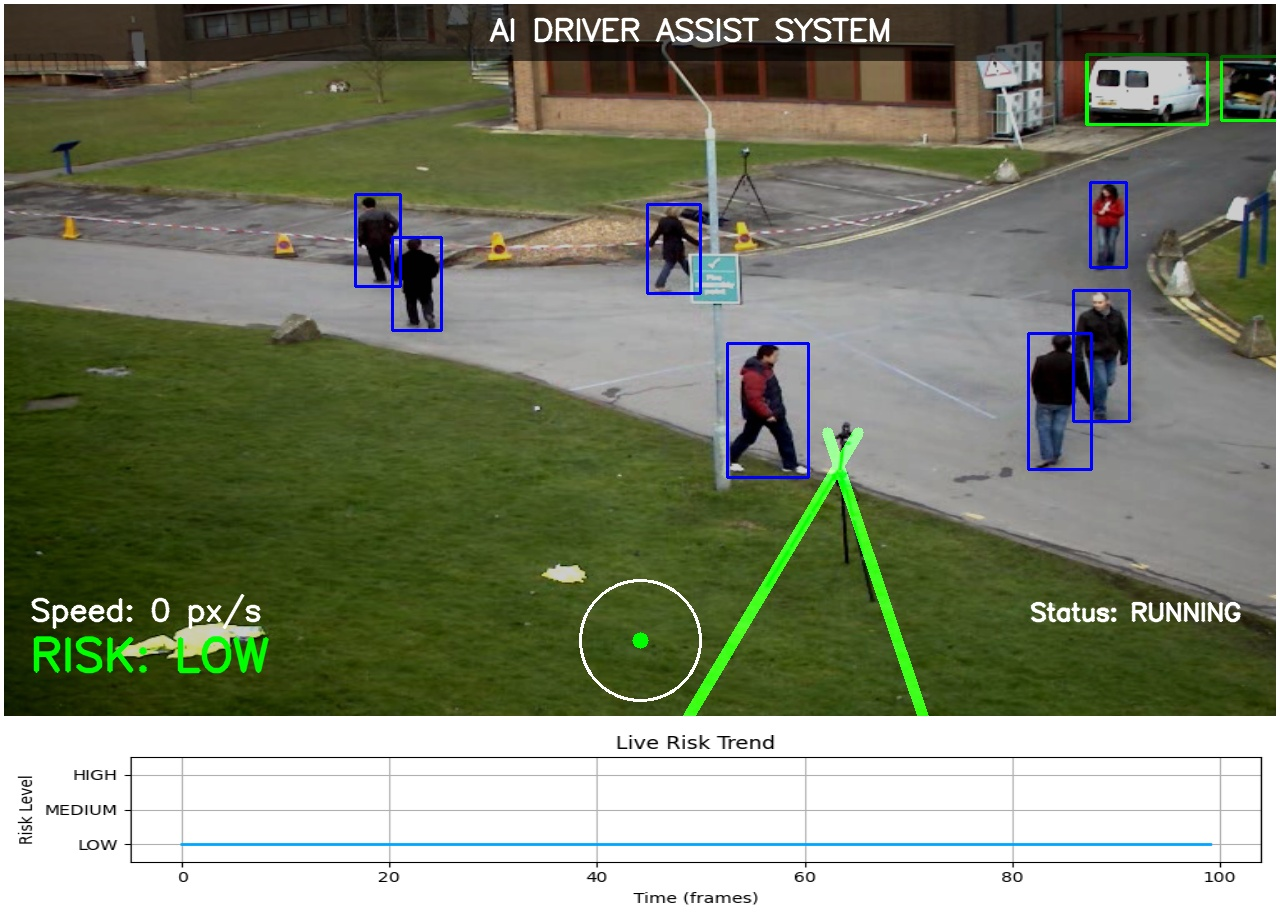

Processing complete.


In [113]:
import cv2
import os
from IPython.display import display, Image, clear_output
import time

# Import the system classes from the modular files
from main import DriverAssistSystem

def run_inline_system(video_path):
    system = DriverAssistSystem(yolo_model_path='yolov8n.pt')

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return

    # Create a display handle for inline updates
    display_handle = display(None, display_id=True)

    frame_idx = 0
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Process the frame using our modular logic
            processed_frame = system.process_frame(frame, frame_idx)

            # Encode to JPEG bytes
            # (processed_frame is RGB, but cv2.imencode expects BGR by default,
            # however, for web display purposes, the color mapping remains consistent here)
            _, encoded_image = cv2.imencode('.jpg', cv2.cvtColor(processed_frame, cv2.COLOR_RGB2BGR))

            # Update the inline display
            display_handle.update(Image(data=encoded_image.tobytes()))

            frame_idx += 1
            # Small sleep to prevent browser lag during high-speed processing
            time.sleep(0.01)

    except KeyboardInterrupt:
        print("Stopped by user.")
    finally:
        cap.release()
        print("Processing complete.")

# Execute the inline system with the Highway video
test_video = 'videos/Highway.mp4'
if os.path.exists(test_video):
    print(f"Starting inline display for: {test_video}")
    run_inline_system(test_video)
else:
    print(f"Error: {test_video} not found. Please ensure the download step finished.")

In [133]:
import os
import threading
import cv2
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# Import modular components
from main import DriverAssistSystem
from config import FRAME_WIDTH, FRAME_HEIGHT, GRAPH_HEIGHT

# --- UI Components ---
video_folder = 'videos/'
video_files = [f for f in os.listdir(video_folder) if f.endswith(('.mp4', '.avi', '.mov'))]

video_dropdown = widgets.Dropdown(
    options={f: os.path.join(video_folder, f) for f in video_files},
    description='Video:',
    style={'description_width': 'initial'}
)

play_button = widgets.Button(description="Play", button_style='success', icon='play')
pause_button = widgets.Button(description="Pause", button_style='warning', icon='pause', disabled=True)
status_label = widgets.Label(value="Status: READY")
image_widget = widgets.Image(format='jpeg', width=800) # Scaled for Colab view

# --- Global State ---
is_running = False
stop_event = threading.Event()

def process_video_stream(video_path):
    global is_running
    system = DriverAssistSystem()
    cap = cv2.VideoCapture(video_path)

    frame_idx = 0
    while not stop_event.is_set() and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            status_label.value = "Status: Finished"
            break

        # Use modular logic for processing
        processed_frame = system.process_frame(frame, frame_idx)

        # Convert RGB to BGR for encoding
        bgr_frame = cv2.cvtColor(processed_frame, cv2.COLOR_RGB2BGR)
        _, encoded = cv2.imencode('.jpg', bgr_frame)
        image_widget.value = encoded.tobytes()

        frame_idx += 1
        time.sleep(0.01) # UI throttle

    cap.release()
    is_running = False
    play_button.disabled = False
    pause_button.disabled = True

def on_play_clicked(b):
    global is_running
    if not is_running:
        is_running = True
        stop_event.clear()
        play_button.disabled = True
        pause_button.disabled = False
        status_label.value = f"Status: Processing {os.path.basename(video_dropdown.value)}"
        threading.Thread(target=process_video_stream, args=(video_dropdown.value,)).start()

def on_pause_clicked(b):
    stop_event.set()
    status_label.value = "Status: Stopped"

play_button.on_click(on_play_clicked)
pause_button.on_click(on_pause_clicked)

# Layout
controls = widgets.HBox([video_dropdown, play_button, pause_button, status_label])
display(widgets.VBox([controls, image_widget]))

Initializing Driver Assist System...


In [ ]:
import json
import os

def fix_widget_metadata(notebook_path):
    if not os.path.exists(notebook_path):
        print(f"File {notebook_path} not found.")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    # Check if widgets metadata exists
    if 'widgets' in nb.get('metadata', {}):
        print("Found 'widgets' in metadata. Removing to fix rendering error...")
        del nb['metadata']['widgets']

        with open(notebook_path, 'w', encoding='utf-8') as f:
            json.dump(nb, f, indent=1)
        print("Metadata cleaned. You can now try rendering/downloading again.")
    else:
        print("No 'widgets' key found in metadata. The notebook might already be clean.")

# Identify the current notebook filename (usually 'Untitled.ipynb' if not renamed)
# In Colab, we can try to find the most recent .ipynb file in the current session if unknown
notebook_files = [f for f in os.listdir('.') if f.endswith('.ipynb')]
for nb_file in notebook_files:
    fix_widget_metadata(nb_file)

In [ ]:
import os
# Re-verifying the cleanup to ensure metadata is purged
notebook_files = [f for f in os.listdir('.') if f.endswith('.ipynb')]
if not notebook_files:
    print('No .ipynb files found to clean.')
else:
    for nb_file in notebook_files:
        print(f'Checking {nb_file}...')
        fix_widget_metadata(nb_file)